# Notebook to develop codes:

**Remark:** 
 * I work in my local branch (edmond-dev)
 * For now it turns with `desilike/dr2-dev`

In [1]:
"""
Script to fit png from the data.
"""

import logging

import os
from pathlib import Path
import functools

import numpy as np
import matplotlib.pyplot as plt

logger = logging.getLogger('FIT PNG')


# disable jax warning:
logging.getLogger("jax._src.xla_bridge").setLevel(logging.ERROR)
logging.getLogger("jax._src.distributed").setLevel(logging.ERROR)
# Remove warning from jax
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'


In [2]:
from tools import read_data, rebin_data, get_observable_and_likelihood, build_total_likelihood, plot_observables, run_profiler, run_mcmc, plot_triangle

def plot_corr(cov, fn=None): 
    import matplotlib.text
    import re
    
    fig = cov.plot(corrcoef=True, figsize=(9,9))
    for txt in fig.findobj(matplotlib.text.Text):
        s = txt.get_text()
        s = s.replace('spectrum2,', '').replace(',spectrum2', '').replace('spectrum2', '')
        s = re.sub(r'\b(\w+)_\1\b', r'\1', s)   # LRG_LRG -> LRG
        s = s.replace('_', 'x')                 # LRG_QSO -> LRGxQSO
        s = s.replace('\nx ', '\n')             # remove "x " prefix on second line
        if '\n' in s: txt.set_fontsize(8)
        txt.set_text(s)
    if fn is not None: plt.savefig(fn)
    plt.show()

In [ ]:
from clustering_statistics import setup_logging
 
from mpi4py import MPI
setup_logging(level=(logging.INFO if MPI.COMM_WORLD.rank == 0 else logging.ERROR))

data_dir =  '/Users/edmond/Work/data/desi/dr2/summary_statistics/local_png/base/desi-data/loa-v1/v2/fNL/blinded'
mocks_dir = '/Users/edmond/Work/data/desi/dr2/summary_statistics/local_png/base/'

logger.info(f'Load data from: {data_dir} and mocks from: {mocks_dir}')

[Mac.dhcp.lbnl.us:20041] shmem: mmap: an error occurred while determining whether or not /var/folders/vh/lq2m97v91l34jy4xn7vjsr5h0000gn/T//ompi.Mac.501/jf.0/271384576/sm_segment.Mac.501.102d0000.0 could be created.


[000000.00] [0/1] 04-23 14:52  FIT PNG                   INFO     Load data from: stats_dir: /Users/edmond/Work/data/desi/dr2/summary_statistics/local_png/base/desi-data/loa-v1/v2/fNL/blinded


In [ ]:
def propose_fiducial():
    propose_fiducial = {}

    propose_fiducial['LRG'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.4, 1.1), 'region': 'GCcomb', 
                               'use_ell2': True, 'kmin': 1e-3, 'kmax': 0.08, 'kmin_ell2': 1e-3, 'kmax_ell2': 0.08}
    propose_fiducial['ELG'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.6), 'region': 'GCcomb', 
                               'use_ell2': True, 'kmin': 1e-2, 'kmax': 0.08, 'kmin_ell2': 1e-3, 'kmax_ell2': 0.08}  #6e-3
    propose_fiducial['QSO'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 3.5), 'region': 'GCcomb', 
                               'use_ell2': True, 'kmin': 1e-3, 'kmax': 0.08, 'kmin_ell2': 1e-3, 'kmax_ell2': 0.08}   
    
    propose_fiducial['LRGxQSO'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.1), 'region': 'GCcomb', 
                                   'use_ell2': True, 'kmin': 4e-3, 'kmax': 0.08, 'kmin_ell2': 3e-3, 'kmax_ell2': 0.08}   
    propose_fiducial['LRGxELG'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.1), 'region': 'GCcomb', 
                                   'use_ell2': True, 'kmin': 1e-3, 'kmax': 0.08, 'kmin_ell2': 1e-3, 'kmax_ell2': 0.08}   
    propose_fiducial['ELGxQSO'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.6), 'region': 'GCcomb', 
                                   'use_ell2': True, 'kmin': 4e-3, 'kmax': 0.08, 'kmin_ell2': 3e-3, 'kmax_ell2': 0.08}   
    
    # when sort tracer name, ELG arrive first, so it is convienient to have it here as well 
    propose_fiducial['ELGxLRG'] = propose_fiducial['ELGxQSO']
      
    return propose_fiducial

fiducial = propose_fiducial()
tracers_to_read = ['LRG', 'ELGnotqso', 'QSO', 'LRGxQSO', 'LRGxELGnotqso', 'ELGnotqsoxQSO']

pks, windows, covs, zeffs = {}, {}, {}, {}
for tracer in tracers_to_read:
    short_tracer = tracer.replace('_zcmb', '')
    short_tracer = short_tracer.replace('notqso', '')

    pk, window, cov, mocks = read_data(data_dir=data_dir, mocks_dir=mocks_dir, tracer=tracer, add_ic=True, 
                                   aladr1=False, weight_type_mocks='default-fkp-oqe', **fiducial[short_tracer])
    pk, window, cov, mocks = rebin_data(pk, window, cov, mocks, tracer=tracer, **fiducial[short_tracer])
    try: 
        logger.info(f'After rebinning and k range selection: {pk.get(0).k.shape[0]} and {pk.get(2).k.shape[0]} data points.')
    except KeyError:
        logger.info(f'After rebinning and k range selection: {pk.get(0).k.shape[0]} data points.')
   
    if 'x' not in short_tracer: short_tracer = 'x'.join(2*[short_tracer])
    pks[short_tracer], windows[short_tracer], covs[short_tracer] = pk, window, cov

    zeffs[short_tracer] = {}
    zeffs[short_tracer][0] = windows[short_tracer].observable.get(0).attrs['zeff']
    try: 
        zeffs[short_tracer][2] = windows[short_tracer].observable.get(2).attrs['zeff']
    except KeyError:
        pass

[001221.64] [0/1] 04-23 15:13  PNG fitting tools         INFO     Reading the window with integral constraint contribution...
[001221.68] [0/1] 04-23 15:13  FIT PNG                   INFO     After rebinning and k range selection: 31 and 14 data points.
[001221.68] [0/1] 04-23 15:13  PNG fitting tools         INFO     Reading the window with integral constraint contribution...
[001221.71] [0/1] 04-23 15:13  FIT PNG                   INFO     After rebinning and k range selection: 22 and 14 data points.
[001221.71] [0/1] 04-23 15:13  PNG fitting tools         INFO     Reading the window with integral constraint contribution...
[001221.73] [0/1] 04-23 15:13  FIT PNG                   INFO     After rebinning and k range selection: 31 and 14 data points.
[001221.74] [0/1] 04-23 15:13  PNG fitting tools         INFO     Reading the window with integral constraint contribution...
[001221.79] [0/1] 04-23 15:13  FIT PNG                   INFO     After rebinning and k range selection: 28 and 

In [51]:
tracers = ['LRGxLRG', 'ELGxELG', 'QSOxQSO', 'LRGxQSO', 'LRGxELG', 'ELGxQSO']

# just to have a coherent value of b1 in the cross correlation.
kwargs = {'LRG_cross_ell0.b1': 2.15, 'ELG_cross_ell0.b1': 1.2}

observables, likelihoods, profilers = {}, {}, {}
for tracer in tracers:
    observables[tracer], likelihoods[tracer] = get_observable_and_likelihood(pks[tracer], windows[tracer], covs[tracer], tracer, zeffs, engine='camb', **kwargs)
    profilers[tracer] = run_profiler(likelihoods[tracer])

[001223.72] [0/1] 04-23 15:13  PNG fitting tools         INFO     tracers_theo=['LRG_ell0'], ell=0, zeff=0.8178
[001223.79] [0/1] 04-23 15:13  PNG fitting tools         INFO     tracers_theo=['LRG_ell2'], ell=2, zeff=0.814
[001223.85] [0/1] 04-23 15:13  PNG fitting tools         INFO     Using analytical covariance matrix.
[001225.21] [0/1] 04-23 15:13  MinuitProfiler            INFO     Varied parameters: ['fnl_loc', 'LRG_ell0.sn0', 'LRG_ell0.b1', 'LRG_ell0.sigmas'].
[001225.41] [0/1] 04-23 15:13  MinuitProfiler            INFO     Successfully jit input likelihood.
[001226.27] [0/1] 04-23 15:13  PNG fitting tools         INFO     
+-------------------------------------+--------+---------+-------+
| chi2 / (45 - 4) = 41.51 / 41 = 1.01 | varied | bestfit | error |
+-------------------------------------+--------+---------+-------+
|               fnl_loc               |  True  |   6.5   |  5.6  |
|            LRG_ell0.sn0             |  True  | -0.022  | 0.050 |
|             LRG_ell0.b

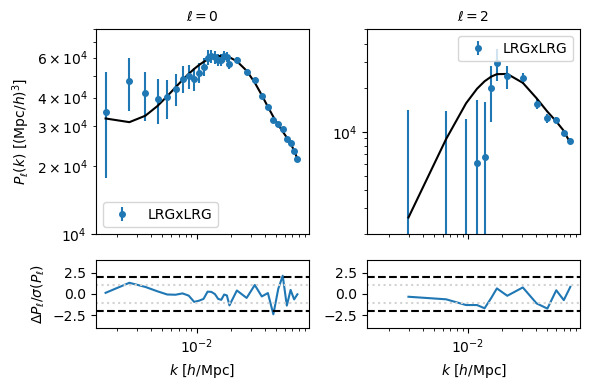

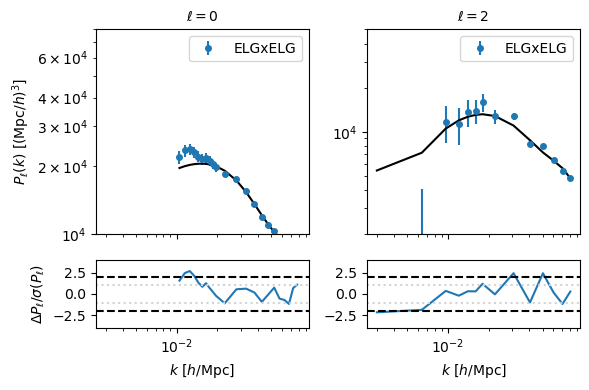

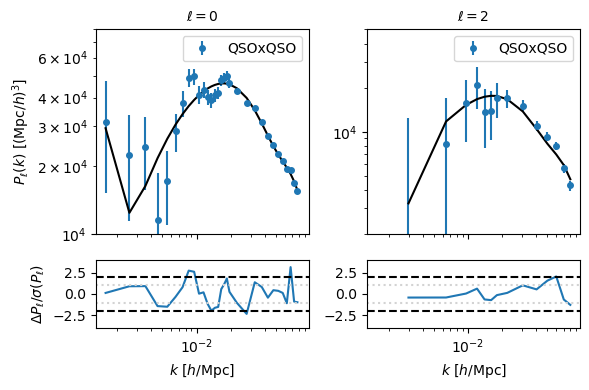

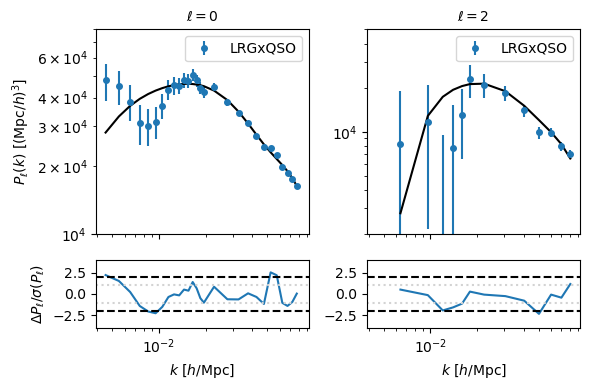

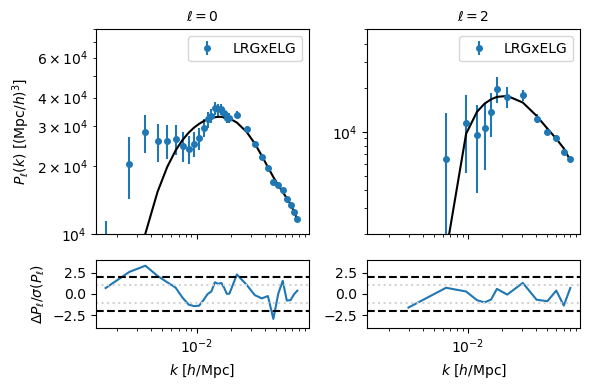

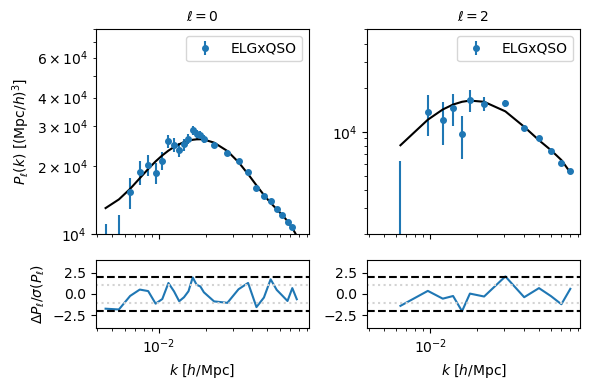

In [52]:
#plot_observables(observables)
for tracer in observables.keys():
    plot_observables({tracer: observables[tracer]})

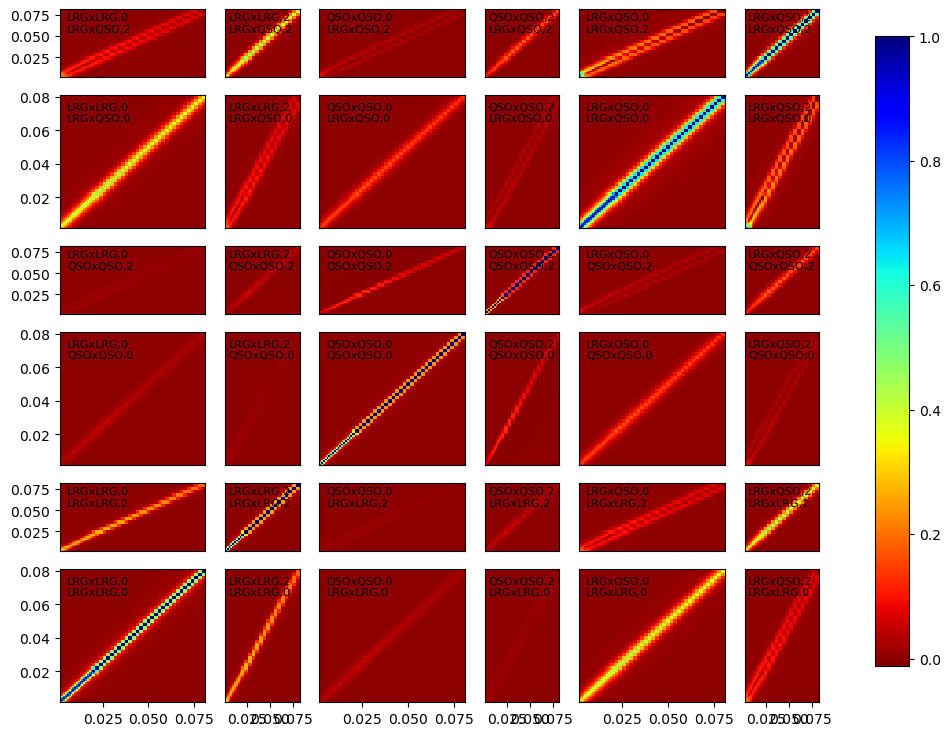

[000174.81] [0/1] 04-13 17:30  MinuitProfiler            INFO     Varied parameters: ['fnl_loc', 'LRG_cross_ell0xQSO_cross_ell0.sn0', 'QSO_cross_ell0.sigmas', 'QSO_ell0.sn0', 'QSO_ell0.b1', 'QSO_ell0.sigmas', 'LRG_ell0.sn0', 'LRG_ell0.b1', 'LRG_ell0.sigmas'].
[000175.66] [0/1] 04-13 17:30  MinuitProfiler            INFO     Successfully jit input likelihood.
[000319.42] [0/1] 04-13 17:33  PNG fitting tools         INFO     
+------------------------------------------+--------+-----------+---------+
| chi2 / (222 - 9) = 3109.24 / 213 = 14.60 | varied |  bestfit  |  error  |
+------------------------------------------+--------+-----------+---------+
|                 fnl_loc                  |  True  | -22.72362 | 0.00055 |
|    LRG_cross_ell0xQSO_cross_ell0.sn0     |  True  |  0.3404   | 0.0052  |
|          QSO_cross_ell0.sigmas           |  True  |   0.00    |  0.69   |
|               QSO_ell0.sn0               |  True  |   0.918   |  0.013  |
|               QSO_ell0.b1             

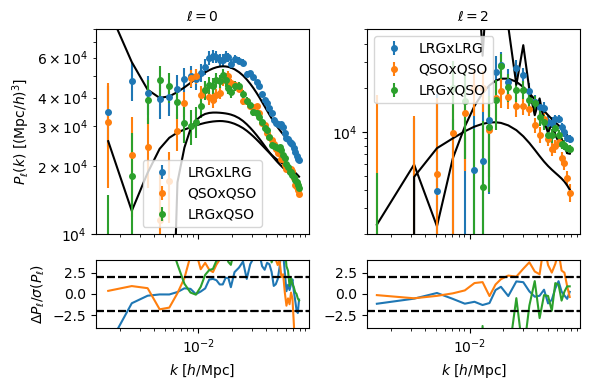

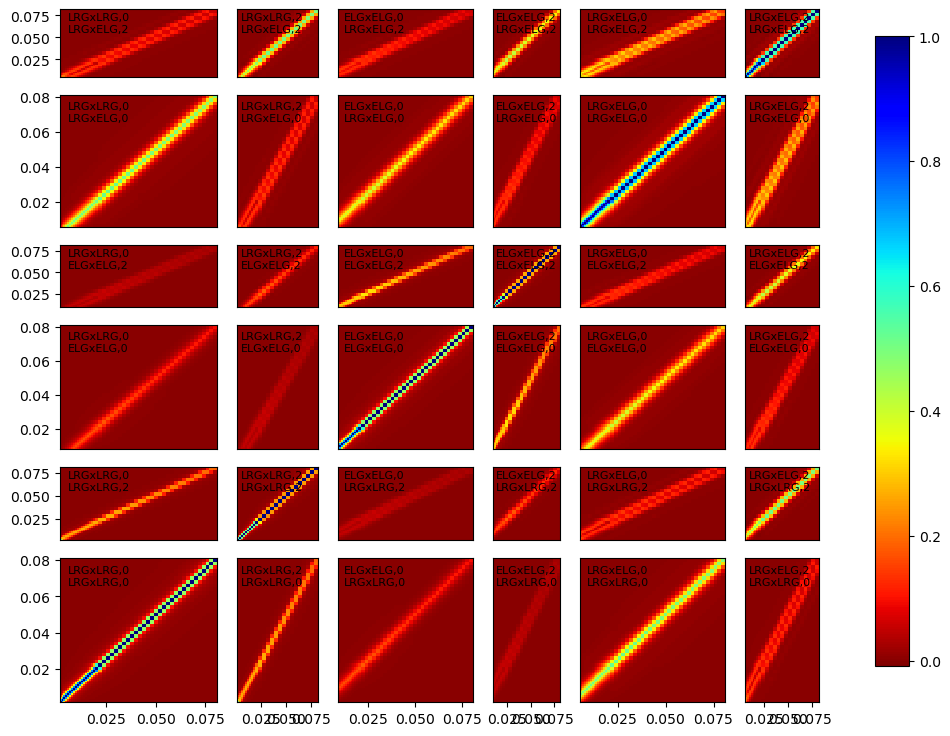

[000321.96] [0/1] 04-13 17:33  MinuitProfiler            INFO     Varied parameters: ['fnl_loc', 'LRG_cross_ell0xELG_cross_ell0.sn0', 'ELG_cross_ell0.sigmas', 'ELG_ell0.sn0', 'ELG_ell0.b1', 'ELG_ell0.sigmas', 'LRG_ell0.sn0', 'LRG_ell0.b1', 'LRG_ell0.sigmas'].
[000322.75] [0/1] 04-13 17:33  MinuitProfiler            INFO     Successfully jit input likelihood.
[000446.97] [0/1] 04-13 17:35  PNG fitting tools         INFO     
+---------------------------------------------------+--------+---------+-------+
| chi2 / (205 - 9) = 120961870.49 / 196 = 617152.40 | varied | bestfit | error |
+---------------------------------------------------+--------+---------+-------+
|                      fnl_loc                      |  True  | -5.3e0  |  nan  |
|         LRG_cross_ell0xELG_cross_ell0.sn0         |  True  | 6.1e-2  |  nan  |
|               ELG_cross_ell0.sigmas               |  True  | 10.0e0  |  nan  |
|                   ELG_ell0.sn0                    |  True  | 5.2e-1  |  nan  |
|    

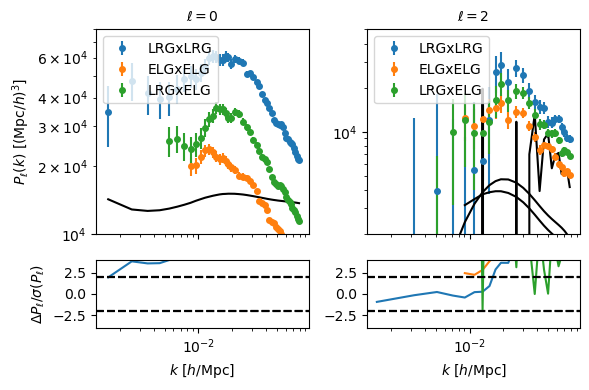

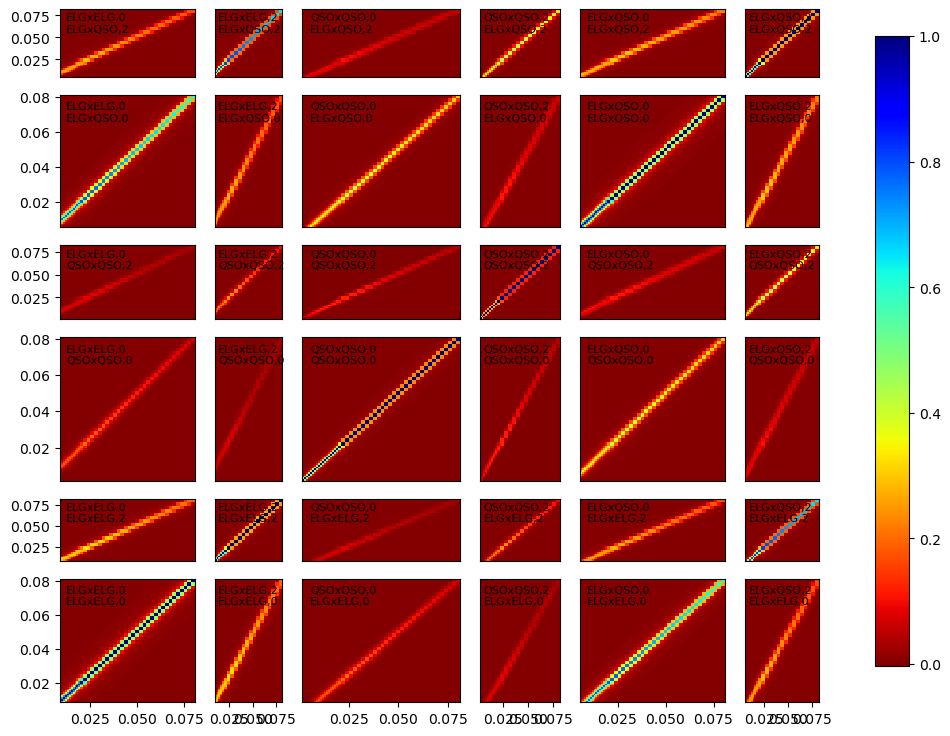

[000449.80] [0/1] 04-13 17:35  MinuitProfiler            INFO     Varied parameters: ['fnl_loc', 'ELG_cross_ell0xQSO_cross_ell0.sn0', 'QSO_cross_ell0.sigmas', 'QSO_ell0.sn0', 'QSO_ell0.b1', 'QSO_ell0.sigmas', 'ELG_ell0.sn0', 'ELG_ell0.b1', 'ELG_ell0.sigmas'].
[000450.50] [0/1] 04-13 17:35  MinuitProfiler            INFO     Successfully jit input likelihood.
[000469.03] [0/1] 04-13 17:35  PNG fitting tools         INFO     
+----------------------------------------+--------+---------+-------+
| chi2 / (205 - 9) = 369.37 / 196 = 1.88 | varied | bestfit | error |
+----------------------------------------+--------+---------+-------+
|                fnl_loc                 |  True  |   8.5   |  2.9  |
|   ELG_cross_ell0xQSO_cross_ell0.sn0    |  True  |  0.031  | 0.018 |
|         QSO_cross_ell0.sigmas          |  True  |  5.37   | 0.52  |
|              QSO_ell0.sn0              |  True  | -0.116  | 0.037 |
|              QSO_ell0.b1               |  True  |  3.138  | 0.033 |
|           

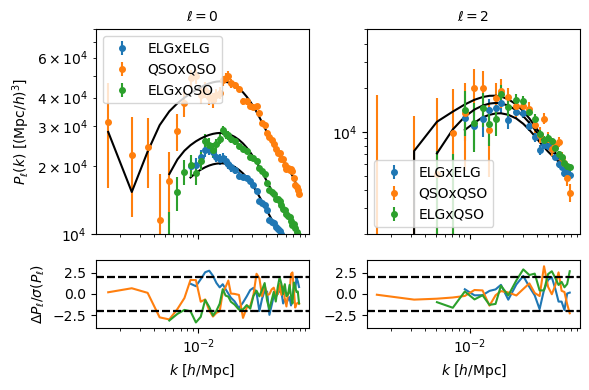

In [ ]:
#order = ['LRGxELG', 'ELGxQSO']
orders = [['LRGxLRG', 'QSOxQSO', 'LRGxQSO'], ['LRGxLRG', 'ELGxELG', 'LRGxELG'], ['ELGxELG', 'QSOxQSO', 'ELGxQSO']]

for order in orders:
    likelihoods['-'.join(order)] = build_total_likelihood(order, pks, observables, covs, zeffs, fiducial)

    if True:
        plot_corr(likelihoods.cov, fn=None)

    profilers['-'.join(order)] = run_profiler(likelihoods['-'.join(order)])
    plot_observables({tt: observables[tt] for tt in order})

In [ ]:
# This does not work for now because I need to name differently the paramters name in the theory to have different bias /sigmas / as a funciton of the three likelihoods !


orders = [['LRGxLRG', 'ELGxELG','QSOxQSO', 'LRGxQSO', 'LRGxELG', 'ELGxQSO']]

for order in orders:
    likelihoods['-'.join(order)] = build_total_likelihood(order, pks, observables, covs, zeffs, fiducial, plot_cov=True)
    profilers['-'.join(order)] = run_profiler(likelihoods['-'.join(order)])
    plot_observables({tt: observables[tt] for tt in order})

In [ ]:
# We do not link the damping term from the cross-correlation and the auto-correlation
# Because they are different effective redshifts and we do not know the a priori.

In [172]:
# samplers = {}

# for tracer in likelihoods.keys():
#     logger.info(f'Run MCMC for {tracer=}:')
#     samplers[tracer] =  run_mcmc(likelihoods[tracer], max_iterations=20000, check_every=5000)

In [173]:
# from desilike.samples import Chain

# burnin, thin = 0.3, 10

# chains = {}

# #chains = Chain.concatenate([Chain.load(fn_chains[key].replace('*', str(i))).remove_burnin(burnin)[::thin] for i in range(nchains)])

# for tracer in samplers.keys():
#      chains[tracer] = Chain.concatenate([chain.remove_burnin(burnin)[::thin] for chain in samplers[tracer].chains])
#      print(f'Nbr points for {tracer=}: {chains[tracer]["fnl_loc"].size}')

# params = ['fnl_loc', 'LRG_ell0.b1', 'LRG_ell0.sn0', 'LRG_ell0.sigmas', 'QSO_ell0.b1', 'QSO_ell0.sn0', 'QSO_ell0.sigmas', 'QSO_cross_ell0.b1', 'LRG_cross_ell0xQSO_cross_ell0.sn0', 'QSO_cross_ell0.sigmas']
# xlabels=[r'$f_{\rm NL}^{\rm loc}$', r'$b_1$', r'$s_{n,0}$', r'$\Sigma_s$', r'$b_1$', r'$s_{n,0}$', r'$\Sigma_s$', r'$b_1$', r'$s_{n,0}$', r'$\Sigma_s$']

# plot_triangle([chains[tracer] for tracer in chains.keys()], params, legend_labels=list(chains.keys()), xlabels=xlabels, 
#               filled=[True]*len(chains), contour_colors=['C0', 'C1', 'C2'], contour_ls=['-', '-', '-'])

# plot_triangle([chains[tracer] for tracer in chains.keys()], ['fnl_loc'], legend_labels=list(chains.keys()), xlabels=[r'$f_{\rm NL}^{\rm loc}$'], 
#               filled=[True]*len(chains), contour_colors=['C0', 'C1', 'C2'], contour_ls=['-', '-', '-'])

In [175]:
## PLUS J4IA PAS UN BEAU PK ALORS QUE AVANT JEN AVAIS UN ! KEPASA ??   --> COMPARER AVEC DR2 FKP 

In [ ]:
import lsstypes 

seeds = [85, 95, 75, 65, 91, 37, 46, 87, 19, 38]

ttest = [lsstypes.read(stats_dir / f'window_mesh2_spectrum_poles_fm_QSO_z0.8-3.5_NGC_weight-default-fkp-oqe_geometry_0_seed={seed}.h5') for seed in seeds]

ttest[2].value()

In [3]:
print(stats_dir)

NameError: name 'stats_dir' is not defined

In [24]:
tt = lsstypes.read(stats_dir / 'window_mesh2_spectrum_poles_fm_QSO_z0.8-3.5_NGC_weight-default-fkp-oqe_geometry_0_seed=1.h5')

In [25]:
tt.value()

array([[ 3.59774105e-01,  1.14347095e-02, -1.48626313e-04, ...,
        -7.89106102e+00,  4.47599972e+00,  1.09536495e+00],
       [ 5.04086318e-01, -6.35115514e-03,  7.50905318e-03, ...,
         9.08098369e-01,  1.61208473e+00, -4.66202297e+00],
       [ 5.59016867e-01,  6.52128506e-03,  1.70447782e-02, ...,
         5.12298302e-01,  2.78599483e+00, -1.39614329e+01],
       ...,
       [ 9.83820667e-06,  7.72027084e-04,  2.19541942e-03, ...,
        -9.53069456e-03,  5.10627048e-02, -7.86010903e-02],
       [ 1.91603948e-05,  7.41575997e-04,  2.01276517e-03, ...,
        -2.57997251e-03,  7.70670757e-02, -4.59769363e-02],
       [ 2.52278176e-05,  7.84904583e-04,  2.03625971e-03, ...,
        -1.52722733e-02,  5.70130979e-02,  1.89816888e-02]],
      shape=(157, 45))